# Solved Example: Grouping Agricultural Fields

This notebook develops a complete unsupervised-learning solution. We inspect the data, prepare the measurements, select a suitable number of groups, fit the model, interpret the groups, and produce recommendations.

## 1. Import libraries

`random_state=42` is used later so that the result is reproducible.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Load the dataset

The path logic allows the notebook to work whether it is launched from this folder or its parent folder.

In [2]:
candidate_paths = [Path("agricultural_fields.csv"), Path("K-Means/agricultural_fields.csv")]
csv_path = next((path for path in candidate_paths if path.exists()), None)
if csv_path is None:
    raise FileNotFoundError("agricultural_fields.csv was not found.")

df = pd.read_csv(csv_path)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 750 rows x 8 columns


,Field_ID,Soil_pH,Moisture_Percent,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm,Organic_Carbon_Percent,Previous_Yield_ton_per_ha
0,FLD-0507,7.71,17.3,50.9,27.1,273.9,0.80,3.58
1,FLD-0358,6.99,25.8,81.0,54.1,213.7,1.44,6.31
2,FLD-0134,5.58,34.7,54.2,25.9,160.6,0.51,3.15
3,FLD-0251,6.43,22.0,73.7,44.6,224.8,1.33,6.74
4,FLD-0300,6.88,24.3,85.3,53.2,190.5,0.89,6.65


## 3. Data-quality checks

Before modelling, verify data types, missing values, duplicate identifiers, and descriptive ranges.

In [3]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))

print("Duplicate Field_ID values:", df["Field_ID"].duplicated().sum())
display(df.describe().round(2))

Data types:


,dtype
Field_ID,str
Soil_pH,float64
Moisture_Percent,float64
Nitrogen_ppm,float64
Phosphorus_ppm,float64
Potassium_ppm,float64
Organic_Carbon_Percent,float64
Previous_Yield_ton_per_ha,float64


Missing values:


,missing_count
Field_ID,0
Soil_pH,0
Moisture_Percent,0
Nitrogen_ppm,0
Phosphorus_ppm,0
Potassium_ppm,0
Organic_Carbon_Percent,0
Previous_Yield_ton_per_ha,0


Duplicate Field_ID values: 0


,Soil_pH,Moisture_Percent,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm,Organic_Carbon_Percent,Previous_Yield_ton_per_ha
count,750.00,750.00,750.00,750.00,750.00,750.00,750.00
mean,6.48,27.47,69.30,42.08,194.16,1.11,5.07
std,0.85,8.57,25.16,16.26,38.95,0.49,1.60
min,4.62,8.80,17.60,8.00,90.00,0.21,1.79
25%,5.81,20.52,46.12,27.72,165.00,0.70,3.60
50%,6.40,27.30,69.05,41.80,191.95,1.04,5.16
75%,7.02,35.10,91.57,55.48,220.48,1.52,6.47
max,8.50,48.00,123.20,80.00,294.30,2.27,8.33


### Observation

The dataset contains 750 observations, no missing values, and no duplicate field IDs. `Field_ID` is excluded from modelling because its number is arbitrary and does not describe soil or crop conditions.

## 4. Select and standardize features

The measurements use very different units. For example, potassium is measured in hundreds of ppm while organic carbon is a small percentage. Standardization gives each feature a mean near 0 and standard deviation near 1, preventing large-scale variables from dominating Euclidean distance.

In [4]:
feature_columns = [column for column in df.columns if column != "Field_ID"]
X = df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_check = pd.DataFrame(X_scaled, columns=feature_columns)
display(scaled_check.agg(["mean", "std"]).round(2))

,Soil_pH,Moisture_Percent,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm,Organic_Carbon_Percent,Previous_Yield_ton_per_ha
mean,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 5. Choose the number of groups

We fit candidate K-Means models for $k=2$ through $k=10$ and compare:

- **Inertia (WCSS):** compactness within groups; lower is better, but it always decreases as $k$ grows. We look for an elbow.
- **Silhouette score:** cohesion versus separation; higher is better.

Using both measures is more defensible than choosing the number of groups by sight alone.

,k,Inertia_WCSS,Silhouette_Score
0,2,2916.944,0.418
1,3,1431.606,0.550
2,4,717.306,0.570
3,5,687.186,0.452
4,6,657.457,0.340
5,7,629.747,0.245
6,8,601.328,0.146
7,9,584.872,0.141
8,10,570.592,0.135


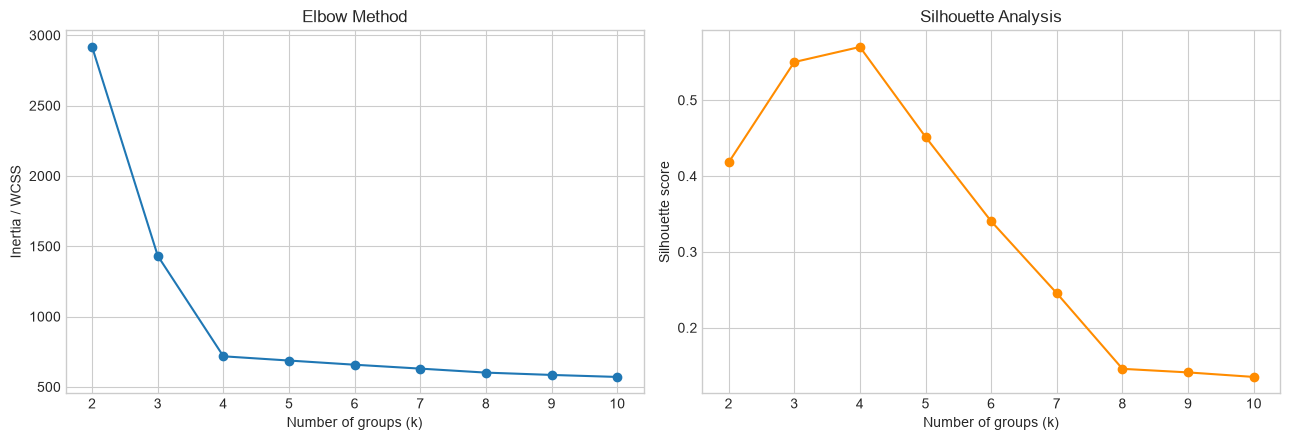

In [5]:
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    candidate = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = candidate.fit_predict(X_scaled)
    inertias.append(candidate.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

evaluation = pd.DataFrame({
    "k": list(k_values),
    "Inertia_WCSS": inertias,
    "Silhouette_Score": silhouettes,
})
display(evaluation.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(evaluation["k"], evaluation["Inertia_WCSS"], marker="o")
axes[0].set(title="Elbow Method", xlabel="Number of groups (k)", ylabel="Inertia / WCSS")
axes[1].plot(evaluation["k"], evaluation["Silhouette_Score"], marker="o", color="darkorange")
axes[1].set(title="Silhouette Analysis", xlabel="Number of groups (k)", ylabel="Silhouette score")
plt.tight_layout()
plt.show()

### Decision

The elbow occurs at **4 groups**, and the silhouette analysis provides quantitative support for this choice. Therefore, we use $k=4$. In real projects, domain knowledge should also be considered before finalizing the number.

## 6. Train the final model

Cluster numbers are arbitrary identifiers; cluster 0 is not inherently better than cluster 1.

In [6]:
final_model = KMeans(n_clusters=4, random_state=42, n_init=20)
df["Cluster"] = final_model.fit_predict(X_scaled)

print("Fields per cluster:")
display(df["Cluster"].value_counts().sort_index().to_frame("Field_Count"))
print("Final silhouette score:", round(silhouette_score(X_scaled, df["Cluster"]), 3))

Fields per cluster:


,Field_Count
Cluster,
0,180
1,210
2,190
3,170


Final silhouette score: 0.57


## 7. Interpret clusters in original units

Means in the original units make the model useful to agronomists. The standardized heatmap then shows which characteristics are relatively high or low across groups.

In [7]:
cluster_profile = df.groupby("Cluster")[feature_columns].mean().round(2)
cluster_profile.insert(0, "Field_Count", df.groupby("Cluster").size())
display(cluster_profile)

,Field_Count,Soil_pH,Moisture_Percent,Nitrogen_ppm,Phosphorus_ppm,Potassium_ppm,Organic_Carbon_Percent,Previous_Yield_ton_per_ha
Cluster,,,,,,,,
0,180,5.45,30.98,39.88,23.94,149.51,0.73,3.15
1,210,6.65,23.79,78.48,48.20,202.99,1.22,5.75
2,190,6.14,38.13,102.15,62.71,180.19,1.78,7.07
3,170,7.74,16.40,52.42,30.69,246.11,0.62,4.03


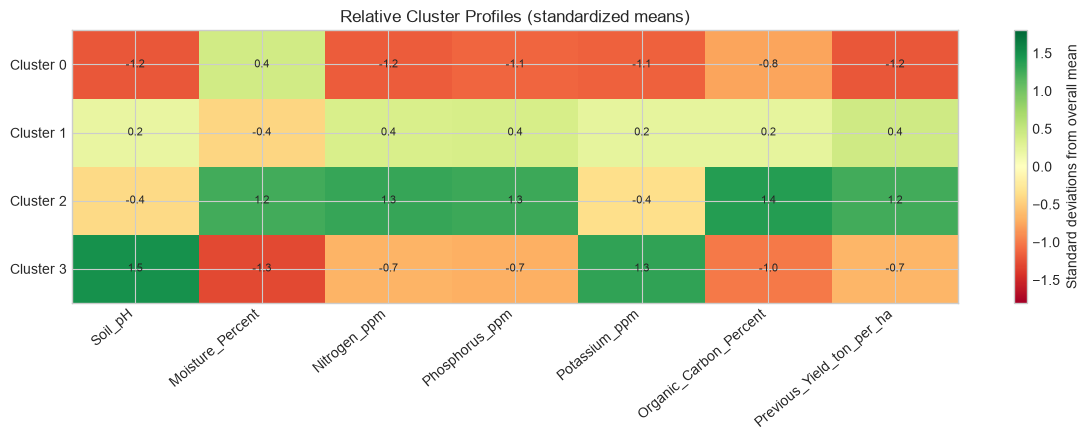

In [8]:
profile_z = df.groupby("Cluster")[feature_columns].mean()
profile_z = (profile_z - X.mean()) / X.std(ddof=0)

fig, ax = plt.subplots(figsize=(12, 4.5))
image = ax.imshow(profile_z, cmap="RdYlGn", aspect="auto", vmin=-1.8, vmax=1.8)
ax.set_xticks(range(len(feature_columns)), labels=feature_columns, rotation=40, ha="right")
ax.set_yticks(range(4), labels=[f"Cluster {i}" for i in profile_z.index])
ax.set_title("Relative Cluster Profiles (standardized means)")
for i in range(profile_z.shape[0]):
    for j in range(profile_z.shape[1]):
        ax.text(j, i, f"{profile_z.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Standard deviations from overall mean")
plt.tight_layout()
plt.show()

## 8. Visualize all seven dimensions with PCA

PCA projects the seven standardized features onto two axes for visualization. The clustering itself still uses all seven features, so this chart is a simplified view rather than the basis of the model.

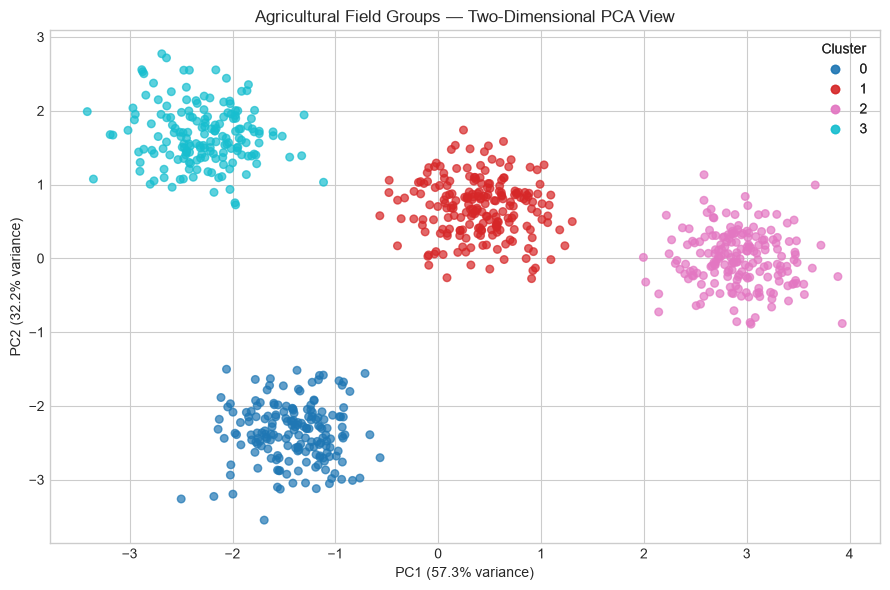

Variance shown by two components: 89.4%


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="tab10", alpha=0.7, s=30)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Agricultural Field Groups — Two-Dimensional PCA View")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

print("Variance shown by two components:", f"{pca.explained_variance_ratio_.sum():.1%}")

## 9. Convert results into recommendations

The exact cluster number attached to each description can be read from the profile table above. A practical interpretation is:

- **Acidic, lower-nutrient fields:** prioritize pH correction based on agronomic testing, then use targeted nutrient management.
- **Balanced, productive fields:** maintain current fertility practices and monitor rather than applying unnecessary inputs.
- **Alkaline, dry fields:** improve irrigation scheduling and choose nutrient formulations suitable for high-pH soil.
- **Moist, nutrient-rich, high-yield fields:** preserve organic matter, monitor drainage, and avoid over-fertilization.

These are screening-level suggestions, not prescriptions. Treatment decisions should also consider crop type, location, weather, cost, and advice from a qualified agronomist.

## 10. Save the field assignments

This produces an operational file containing each field and its assigned group.

In [10]:
output_path = csv_path.with_name("agricultural_fields_with_clusters.csv")
df.to_csv(output_path, index=False)
print(f"Saved: {output_path.resolve()}")
df[["Field_ID", "Cluster"]].head(10)

Saved: C:\manish\ejagruti\genai\myprojects\aiml\K-Means\agricultural_fields_with_clusters.csv


,Field_ID,Cluster
0,FLD-0507,3
1,FLD-0358,1
2,FLD-0134,0
3,FLD-0251,1
4,FLD-0300,1
5,FLD-0681,2
6,FLD-0337,1
7,FLD-0156,0
8,FLD-0529,3
9,FLD-0737,2


## Conclusion

The analysis found four compact, interpretable field profiles. Standardization was essential because the inputs use different units. The elbow method and silhouette score supported the group count, and the original-unit profile table converted numerical clusters into actionable descriptions.

### Important limitations

- K-Means favors roughly compact, spherical groups and can be affected by outliers.
- The result depends on the selected features and their quality.
- Association does not establish that a soil characteristic causes yield.
- Cluster assignments should support—not replace—agronomic judgment.